In [29]:
import pandas as pd

# Cargar precios ajustados
adj_close = pd.read_csv(
    "../Datos_csv/adj_close.csv",
    index_col=0,
    parse_dates=True
)

# Cargar volumen
volume = pd.read_csv(
    "../Datos_csv/volume.csv",
    index_col=0,
    parse_dates=True
)


La metodología se ilustra con un activo representativo. Seleccionamos la varibel principal (retornos en formato logarítmico)

In [30]:
import numpy as np
# Retornos
ret_simple = adj_close.pct_change()
ret_log = np.log(adj_close)
ret_log_diff = np.log(adj_close).diff() #diferencia con el dia anterior
dollar_vol = adj_close * volume


In [31]:
# =========================================================
# 4) Lista de ETFs (sale de las columnas)
# =========================================================
tickers = list(adj_close.columns)
print("Número de ETFs:", len(tickers))
print(" Listado:", tickers)

Número de ETFs: 63
 Listado: ['AGG', 'BIL', 'BND', 'DBC', 'DIA', 'DVY', 'EEM', 'EFA', 'EWG', 'EWJ', 'EWQ', 'EWT', 'EWU', 'EWY', 'EWZ', 'FXI', 'GLD', 'HYG', 'IAU', 'IEF', 'IEFA', 'IEMG', 'IJR', 'INDA', 'ITOT', 'IVV', 'IWD', 'IWF', 'IWM', 'JNK', 'LQD', 'MCHI', 'MDY', 'MTUM', 'QQQ', 'QUAL', 'SCHD', 'SHY', 'SLV', 'SPY', 'TIP', 'TLT', 'USMV', 'USO', 'VEA', 'VIG', 'VLUE', 'VNQ', 'VOO', 'VTI', 'VTV', 'VUG', 'VWO', 'XLB', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLRE', 'XLU', 'XLV', 'XLY']


Se analiza la estacionariedad de distintas transformaciones de la serie con el objetivo de identificar la representación más adecuada para la modelización temporal.

In [32]:
import numpy as np
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tools.sm_exceptions import InterpolationWarning # para quitar el warning de kpss
import warnings
warnings.filterwarnings("ignore", category=InterpolationWarning)

def tests_estacionariedad(serie):
    x = np.asarray(serie, float)
    x = x[~np.isnan(x)]
    # --- ADF (H0: no estacionaria) ---
    adf_stat, adf_p, adf_lags, adf_n, adf_crit, adf_icbest = adfuller(x, autolag='AIC')
    
    # --- KPSS (H0: estacionaria) ---
    # regression='c'  -> estacionaria alrededor de una constante (nivel)
    # regression='ct' -> estacionaria alrededor de una tendencia
    kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(x, regression='c', nlags='auto' )
    if kpss_p <= 0.01 and adf_p>0.01: # rechazamos KPSS, pero no ADF
        s = "no estacionario"
    elif kpss_p > 0.01 and adf_p<=0.01: # rechazamos ADF, pero no KPSS 
        s = "estacionario"
    elif kpss_p > 0.01 and adf_p > 0.01: # no se rechaza nada        
        s = "no concluyente"
    else:
        s = "resultados inconsistentes"  # esto no debe suceder...pero sucede
    return s

In [33]:
# Estacionariedad (una fila por ETF y por serie)
estacionariedad_rows = []

for etf in tickers:
    # print("\n" + "="*60)
    # print(f"ETF: {etf}")
    # print("="*60)

    #  Extraer series del ETF
  
    serie_adj_close     = adj_close[etf].dropna()
    serie_ret_simple    = ret_simple[etf].dropna()
    serie_log_precio    = ret_log[etf].dropna()
    serie_ret_log_diff  = ret_log_diff[etf].dropna()
    serie_dollar_vol    = dollar_vol[etf].dropna()
    serie_volume        = volume[etf].dropna()

    #  Estacionariedad
    # print(f"\n--- Estacionariedad ({etf}) ---")

    series_a_testear = {
        "Adj_close": serie_adj_close,
        "log(Adj_close)": serie_log_precio,
        "retorno_simple": serie_ret_simple,
        "retorno_logaritmico": serie_ret_log_diff,
        "dollar_volume": serie_dollar_vol,
        "volume": serie_volume
    }

    res_est = []
    for nombre, s in series_a_testear.items():
        if len(s) < 50:
            estado = "insuficientes_datos"
        else:
            estado = tests_estacionariedad(s)

        row = {
            "ETF": etf,
            "Serie": nombre,
            "N_obs": len(s),
            "Inicio": s.index.min().date(),
            "Fin": s.index.max().date(),
            "Conclusión": estado
        }
        estacionariedad_rows.append(row)
        res_est.append(row)

    # display(pd.DataFrame(res_est).head(2))

ELIMINAMOS LAS ETFS NO ESTACIONARIAS EN RETORNOS

In [34]:

# Convertimos la lista acumulada en DataFrame
estacionariedad_df = pd.DataFrame(estacionariedad_rows)

# ETFs válidos
etfs_validos = []

# ETFs eliminados
etfs_eliminados = []

for etf in tickers:
    
    # Filtramos solo las filas de ese ETF
    df_etf = estacionariedad_df[estacionariedad_df["ETF"] == etf]
    
    # Sacamos las conclusiones de los retornos
    ret_simple_estado = df_etf[df_etf["Serie"] == "retorno_simple"]["Conclusión"].values
    ret_log_estado    = df_etf[df_etf["Serie"] == "retorno_logaritmico"]["Conclusión"].values
    
    # Comprobamos que existan y sean estacionarios
    if (
        len(ret_simple_estado) > 0 and
        len(ret_log_estado) > 0 and
        ret_simple_estado[0] == "estacionario" or
        ret_log_estado[0] == "estacionario"
    ):
        etfs_validos.append(etf)
    else:
        etfs_eliminados.append(etf)

# Mostrar resultados
print("Número total ETFs originales:", len(tickers))
print("Número ETFs válidos:", len(etfs_validos))
print("Número ETFs eliminados:", len(etfs_eliminados))

print("\nETFs eliminados:")
display(pd.DataFrame(etfs_eliminados, columns=["ETF eliminado"]))

# Sobrescribimos la lista original si quieres trabajar solo con los válidos
tickers_filtrados = etfs_validos


Número total ETFs originales: 63
Número ETFs válidos: 58
Número ETFs eliminados: 5

ETFs eliminados:


,ETF eliminado
0,BIL
1,EWY
2,GLD
3,IAU
4,SHY


Aunque modelar el logaritmo del precio mediante un ARIMA con una diferenciación es matemáticamente equivalente a modelar los retornos logarítmicos, en este trabajo se opta por trabajar directamente con retornos. Esta elección permite una interpretación más clara de los parámetros del modelo y una integración directa con el posterior proceso de optimización de carteras, que se basa en retornos y riesgos esperados.  UTILIZAMOS DE VARIABLE PRINCIPAL LOS RETORNOS LOGARÍTMICOS

In [35]:
# # Seleccionamos solo los primeros 5
# tickers_filtrados = tickers_filtrados[:5]

# print(f"Probando con los siguientes tickers: {tickers_filtrados}")

In [36]:
from pandas.tseries.offsets import DateOffset
splits = {} # aquí guardamos (train, test, cutoff) por ETF
for etf in tickers_filtrados:
    serie_ret_log = ret_log_diff[etf].dropna()

    end_date = serie_ret_log.index.max()
    cutoff = end_date - DateOffset(months=3)

    train = serie_ret_log.loc[:cutoff].dropna()
    test  = serie_ret_log.loc[cutoff + pd.Timedelta(days=1):].dropna()

    # filtros mínimos
    if len(test) < 10 or len(train) < 200:
        continue

    splits[etf] = {
        "cutoff": cutoff,
        "train": train,
        "test": test
    }
    # print("ETF:", etf)
    # print("Cutoff:", cutoff.date())
    # print("Train:", train.index.min().date(), "->", train.index.max().date(), "| n =", len(train))
    # print("Test :", test.index.min().date(),  "->", test.index.max().date(),  "| n =", len(test))


Cutoff: 2025-11-02

Train: 2021-01-05 -> 2025-10-31 | n = 1213


Test : 2025-11-03 -> 2026-02-02 | n = 62

## Búsqueda de mejores parámetros ARIMA

Ljung–Box

Hipótesis nula (H0):Los residuos NO están autocorrelados

p_value alto (> 0.05): NO rechazo H0 → me interesa

p_value bajo (< 0.05): hay autocorrelación → mal modelo

In [37]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tools.sm_exceptions import ValueWarning, ConvergenceWarning

# Warnings fuera
warnings.filterwarnings("ignore", category=ValueWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="Non-invertible starting MA parameters found.*", category=UserWarning)
warnings.filterwarnings("ignore", message="Non-stationary starting autoregressive parameters found.*", category=UserWarning)

resumen_rows = []
preds_por_etf = {}
params_por_etf = {}

p_values = range(0, 6)
q_values = range(0, 6)
d = 0


In [38]:
mejores_modelos = {}

for etf, data in splits.items():
    print(f"\n Seleccionando parámetros ARIMA para: {etf}")
    train = data["train"]
    grid = []
    
    for p in p_values:
        for q in q_values:
            try:
                # Ajuste del modelo
                res = ARIMA(train, order=(p, d, q), trend="n").fit()
                # Test de Ljung-Box para ruido blanco en residuos
                lb = acorr_ljungbox(res.resid.dropna(), lags=[20], return_df=True)
                
                grid.append({
                    "p": p, "q": q, "AIC": res.aic, "BIC": res.bic,
                    "p_value": lb["lb_pvalue"].iloc[-1], "stat": lb["lb_stat"].iloc[-1]
                })
            except: 
                continue

    grid_df = pd.DataFrame(grid)
    
    # Filtrar: No (0,0,0) y que los residuos sean ruido blanco (p_value > 0.05)
    cand = grid_df[(grid_df["p_value"] > 0.05) & ~((grid_df["p"] == 0) & (grid_df["q"] == 0))]
    
    if not cand.empty:
        # Seleccionamos el mejor por AIC/BIC
        best = cand.sort_values(["AIC", "BIC"]).iloc[0]
        order_elegido = (int(best["p"]), 0, int(best["q"]))
        
        # Guardamos en el diccionario
        mejores_modelos[etf] = {
            "order": order_elegido,
            "stats": best.to_dict()
        }
        
        # --- EL PRINT QUE BUSCABAS ---
        print(f" Modelo seleccionado para {etf}: ARIMA{order_elegido}\n")
    else:
        print(f" No se encontró un modelo ARIMA válido para {etf} que supere el test Ljung-Box.\n")




 Seleccionando parámetros ARIMA para: AGG
 Modelo seleccionado para AGG: ARIMA(2, 0, 0)


 Seleccionando parámetros ARIMA para: BND
 Modelo seleccionado para BND: ARIMA(2, 0, 0)


 Seleccionando parámetros ARIMA para: DBC
 Modelo seleccionado para DBC: ARIMA(3, 0, 5)


 Seleccionando parámetros ARIMA para: DIA
 Modelo seleccionado para DIA: ARIMA(1, 0, 0)


 Seleccionando parámetros ARIMA para: DVY
 Modelo seleccionado para DVY: ARIMA(1, 0, 0)


 Seleccionando parámetros ARIMA para: EEM
 Modelo seleccionado para EEM: ARIMA(1, 0, 0)


 Seleccionando parámetros ARIMA para: EFA
 Modelo seleccionado para EFA: ARIMA(1, 0, 0)


 Seleccionando parámetros ARIMA para: EWG
 Modelo seleccionado para EWG: ARIMA(2, 0, 3)


 Seleccionando parámetros ARIMA para: EWJ
 Modelo seleccionado para EWJ: ARIMA(1, 0, 0)


 Seleccionando parámetros ARIMA para: EWQ
 Modelo seleccionado para EWQ: ARIMA(2, 0, 3)


 Seleccionando parámetros ARIMA para: EWT
 Modelo seleccionado para EWT: ARIMA(1, 0, 0)


 Seleccio

## Modelo ARIMA / BASE / CEROS

In [39]:
resultados_preds = {}

for etf, config in mejores_modelos.items():
    print(f"Calculando predicciones para: {etf}")
    order = config["order"]
    y_train = splits[etf]["train"]
    y_test = splits[etf]["test"]
    
    # MODELO ARIMA (Walk-forward)
    history = y_train.copy()
    preds_arima = []
    for val_real in y_test:
        model_fit = ARIMA(history, order=order, trend="n").fit()
        preds_arima.append(model_fit.forecast(steps=1).iloc[0])
        # Actualizamos historia con el valor real
        history = pd.concat([history, pd.Series([val_real], index=[y_test.index[len(preds_arima)-1]])])

    # MODELO BASE (Naive: t = t-1) 
     # el primer valor del test viene del último del train
    preds_base = [y_train.iloc[-1]] + y_test.iloc[:-1].tolist()

    # MODELO ZEROS 
    preds_zeros = np.zeros(len(y_test))

    # Guardamos todo en un DataFrame por ETF
    resultados_preds[etf] = pd.DataFrame({
        "real": y_test,
        "arima": preds_arima,
        "base": preds_base,
        "zeros": preds_zeros
    }, index=y_test.index)

Calculando predicciones para: AGG
Calculando predicciones para: BND
Calculando predicciones para: DBC
Calculando predicciones para: DIA
Calculando predicciones para: DVY
Calculando predicciones para: EEM
Calculando predicciones para: EFA
Calculando predicciones para: EWG
Calculando predicciones para: EWJ
Calculando predicciones para: EWQ
Calculando predicciones para: EWT
Calculando predicciones para: EWU
Calculando predicciones para: EWZ
Calculando predicciones para: FXI
Calculando predicciones para: IEF
Calculando predicciones para: IEFA
Calculando predicciones para: IEMG
Calculando predicciones para: IJR
Calculando predicciones para: INDA
Calculando predicciones para: ITOT
Calculando predicciones para: IVV
Calculando predicciones para: IWD
Calculando predicciones para: IWF
Calculando predicciones para: IWM
Calculando predicciones para: LQD
Calculando predicciones para: MCHI
Calculando predicciones para: MDY
Calculando predicciones para: MTUM
Calculando predicciones para: QQQ
Calculan

## Comparación de Errores

In [40]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

tablas_comparativas = {}

for etf, df in resultados_preds.items():
    y_true = df["real"]
    
    # Diccionario temporal para métricas de este ETF
    metrics = {
        'Modelo': ['ARIMA', 'BASE', 'ZEROS'],
        'MAE': [
            mean_absolute_error(y_true, df["arima"]),
            mean_absolute_error(y_true, df["base"]),
            mean_absolute_error(y_true, df["zeros"])
        ],
        'RMSE': [
            root_mean_squared_error(y_true, df["arima"]),
            root_mean_squared_error(y_true, df["base"]),
            root_mean_squared_error(y_true, df["zeros"])
        ]
    }
    
    res_df = pd.DataFrame(metrics).set_index("Modelo")
    tablas_comparativas[etf] = res_df
    
    print(f"\nResultados para {etf}:")
    display(res_df)


Resultados para AGG:


,MAE,RMSE
Modelo,,
ARIMA,0.001438,0.001822
BASE,0.002090,0.002619
ZEROS,0.001454,0.001840



Resultados para BND:


,MAE,RMSE
Modelo,,
ARIMA,0.001442,0.001800
BASE,0.002096,0.002561
ZEROS,0.001463,0.001814



Resultados para DBC:


...

,MAE,RMSE
Modelo,,
ARIMA,0.006435,0.008351
BASE,0.009771,0.012243
ZEROS,0.006456,0.008359



Resultados para XLV:


,MAE,RMSE
Modelo,,
ARIMA,0.006828,0.008890
BASE,0.009015,0.011374
ZEROS,0.006846,0.008904



Resultados para XLY:


,MAE,RMSE
Modelo,,
ARIMA,0.008644,0.010939
BASE,0.012579,0.015529
ZEROS,0.008677,0.010963


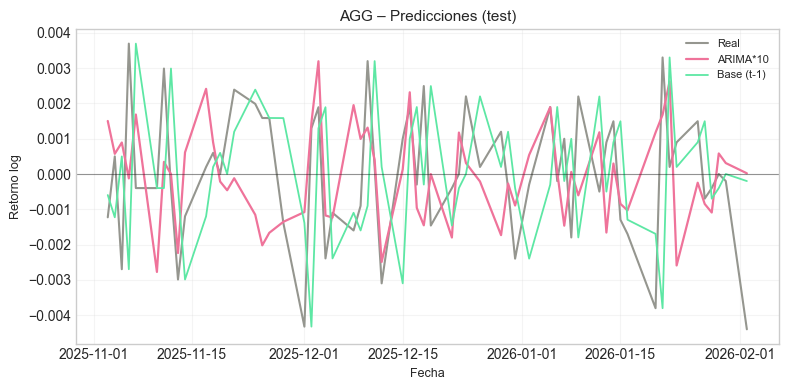

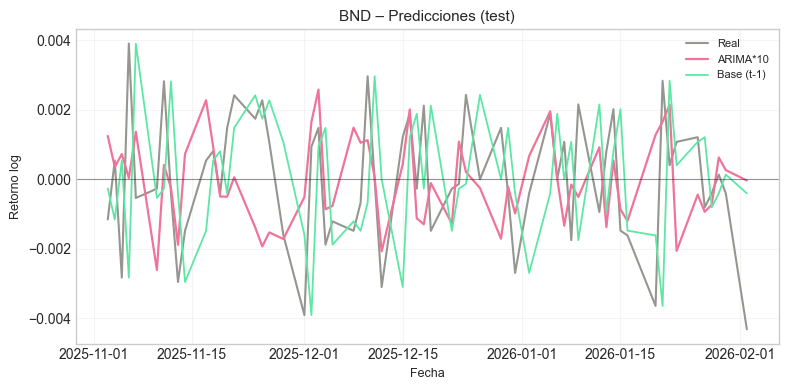

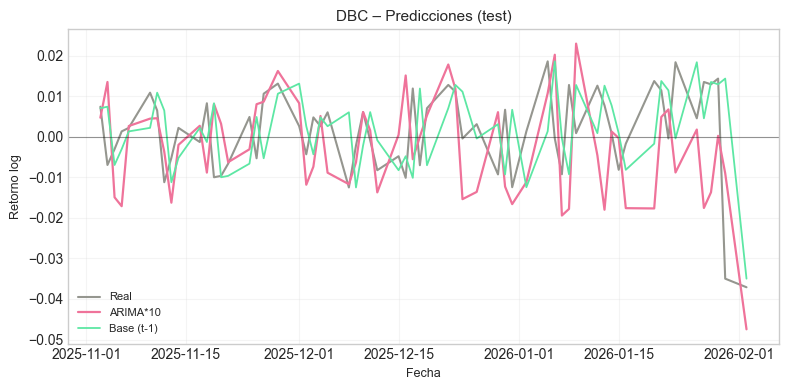

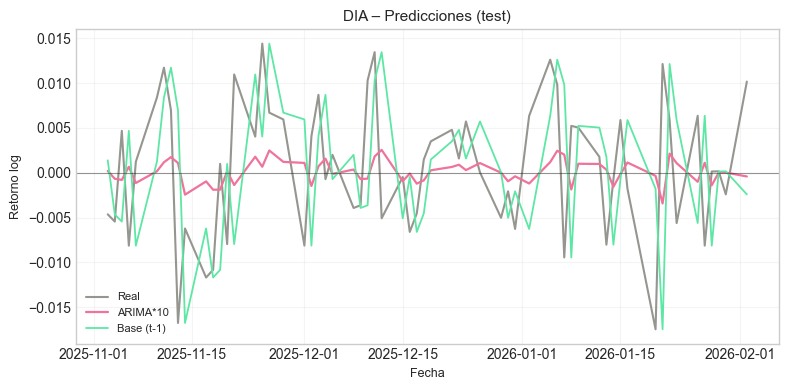

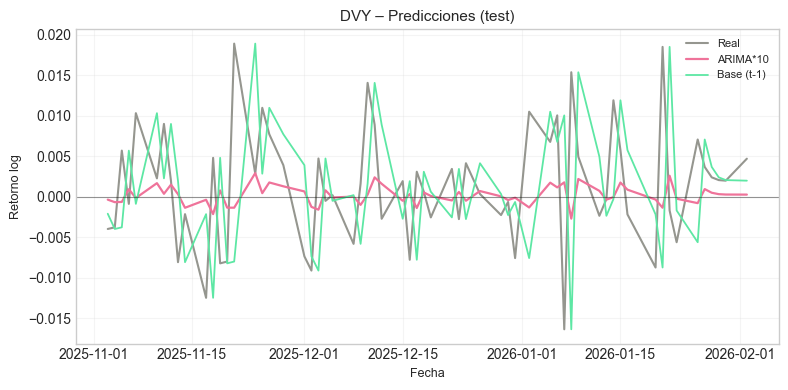

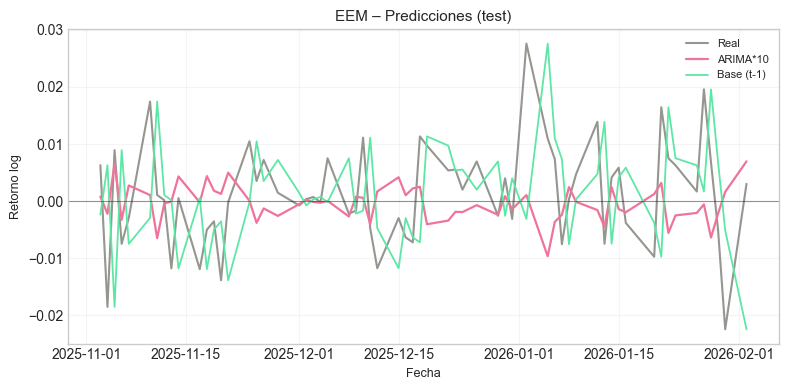

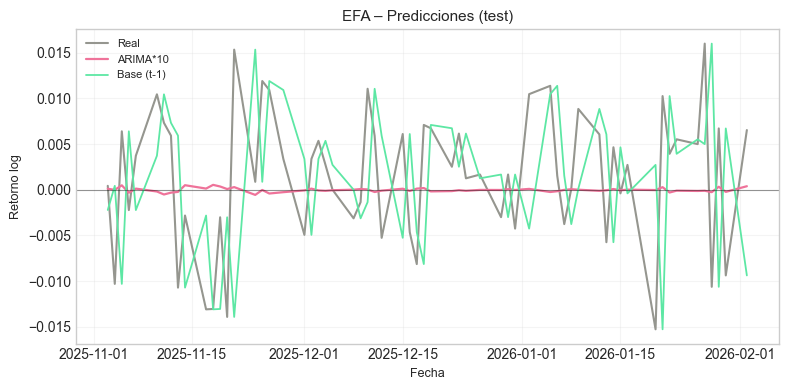

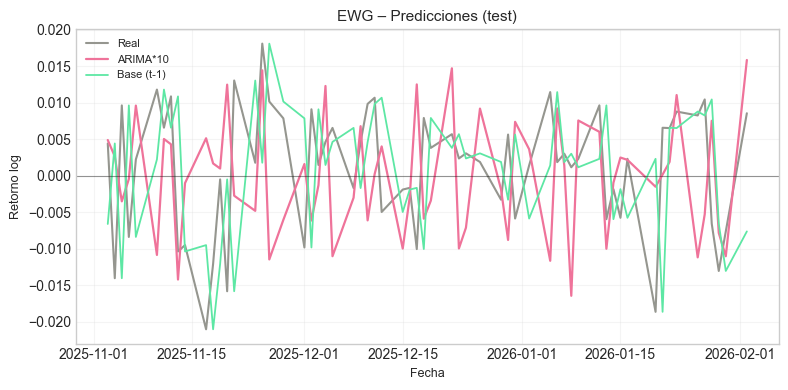

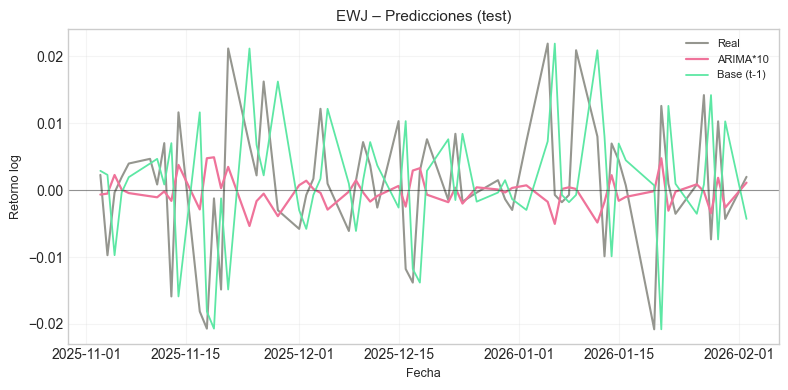

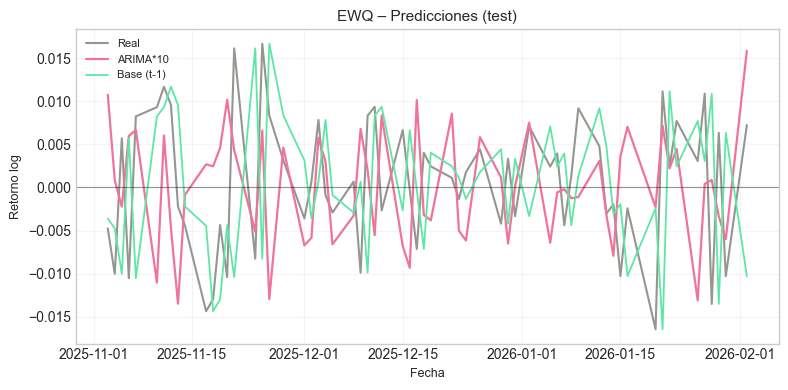

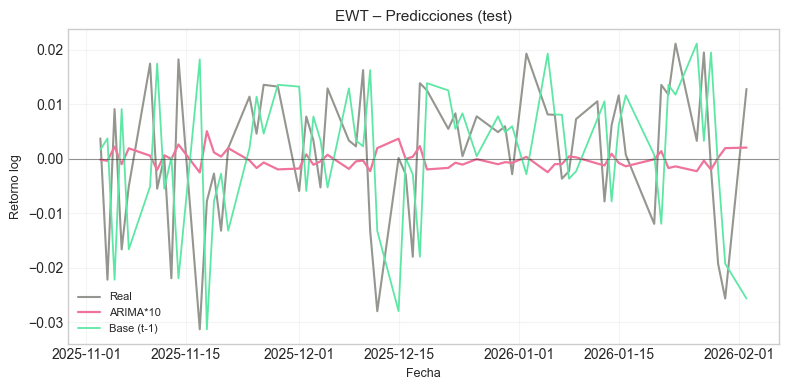

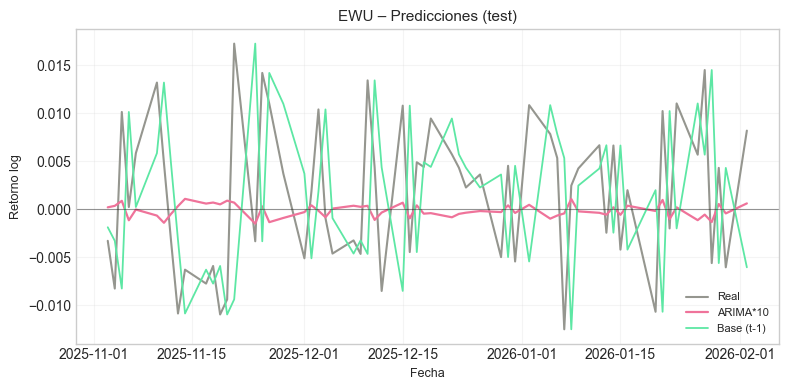

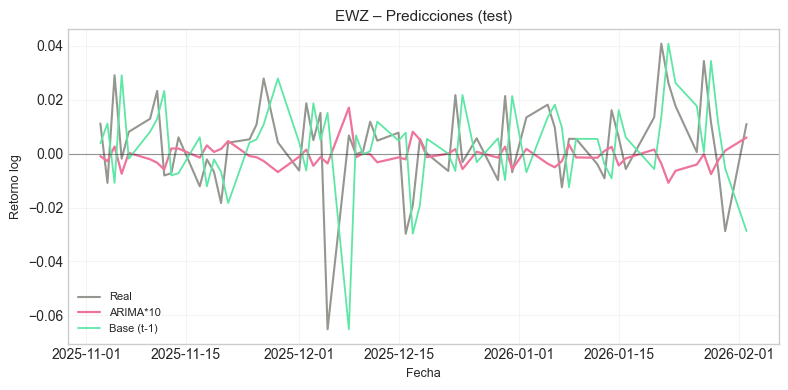

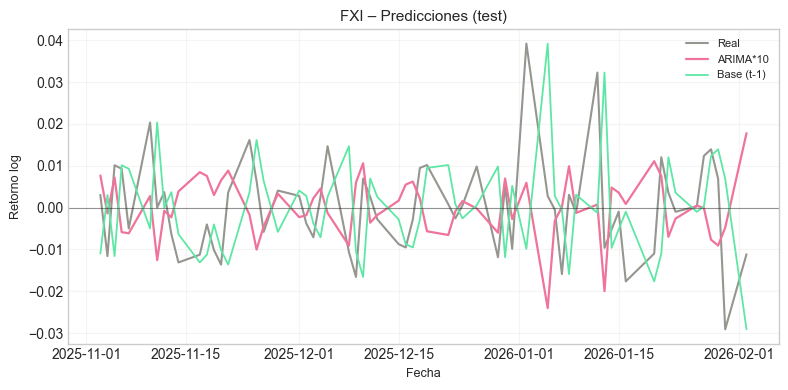

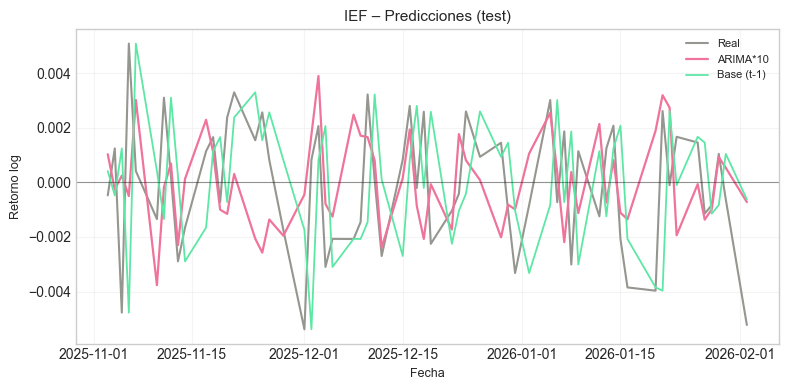

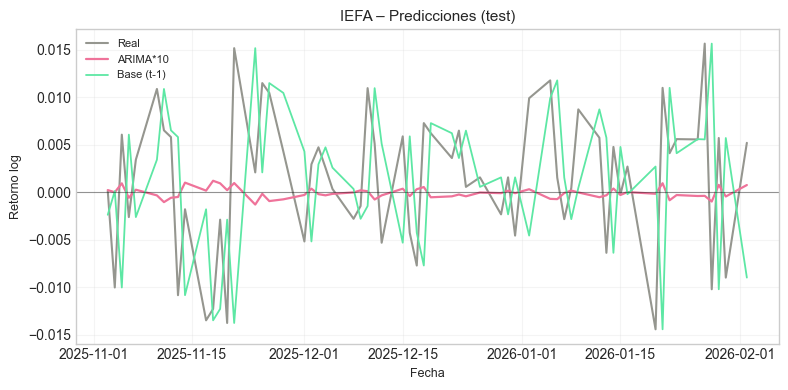

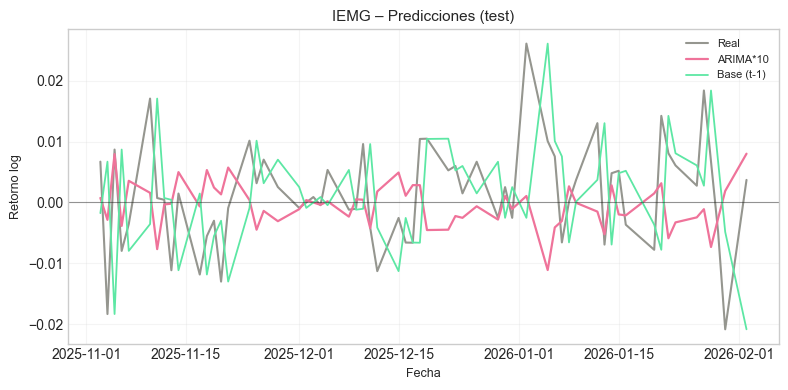

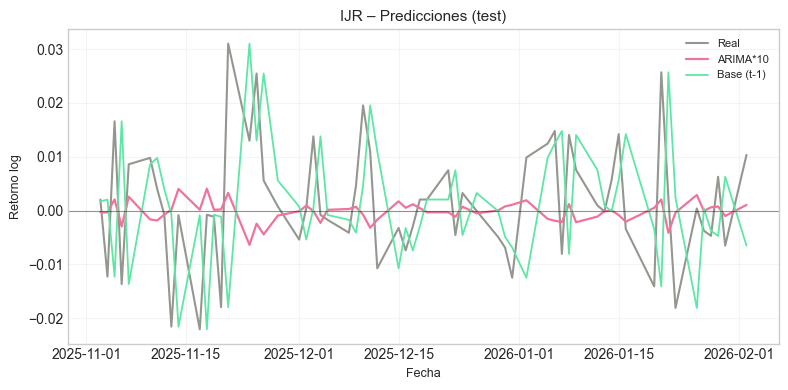

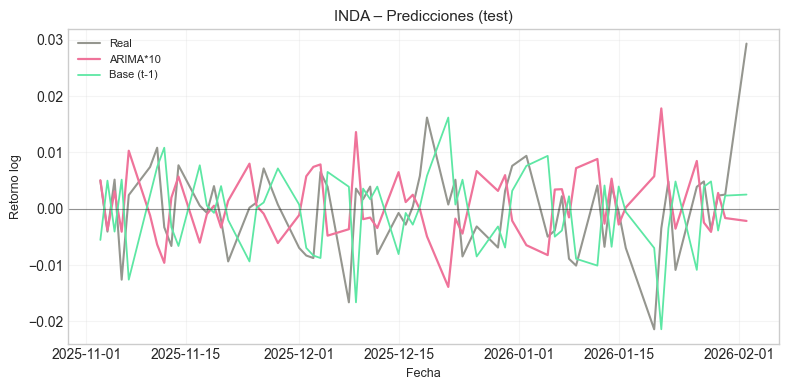

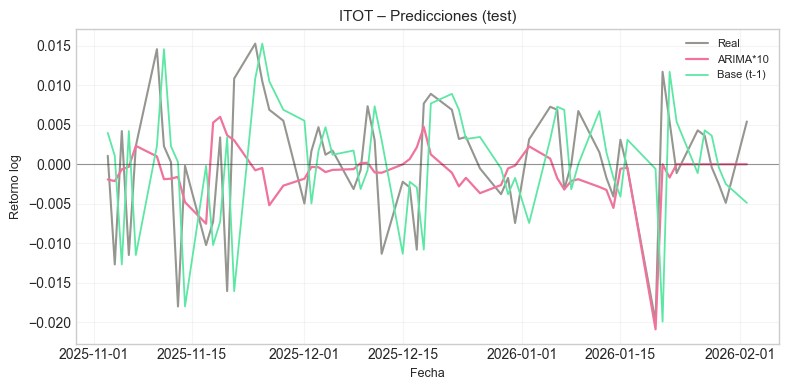

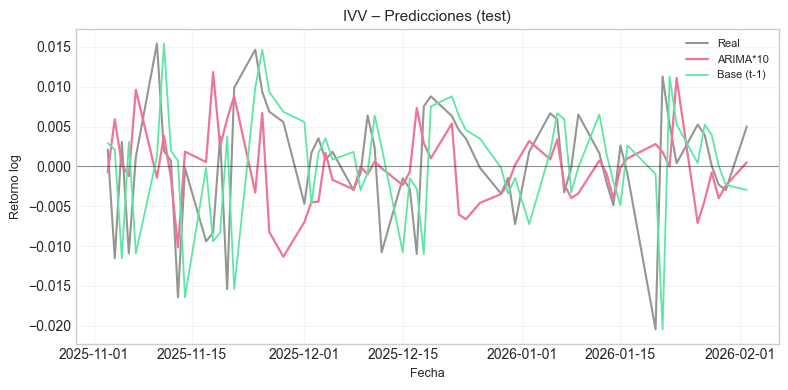

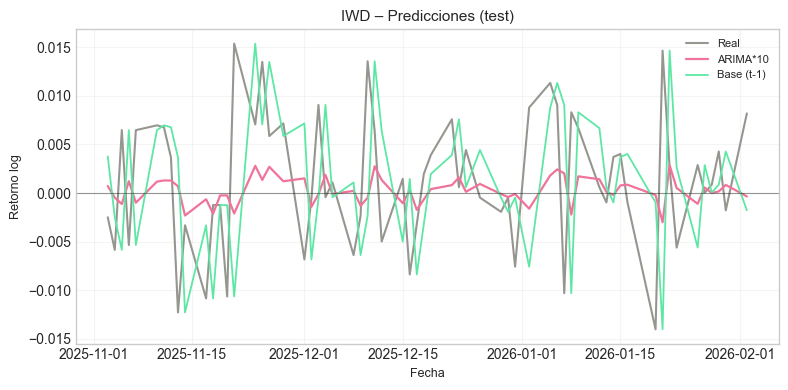

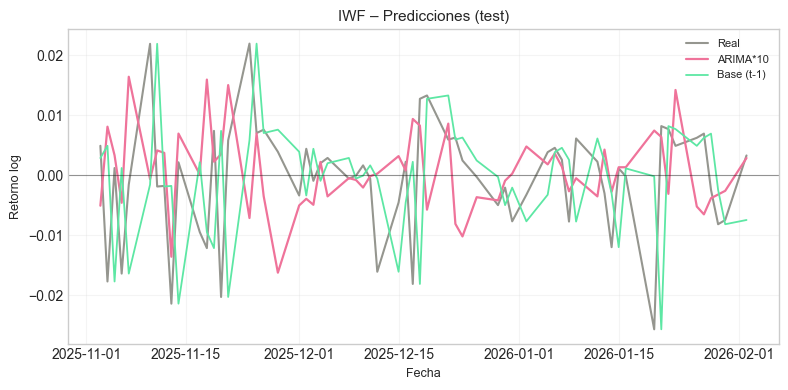

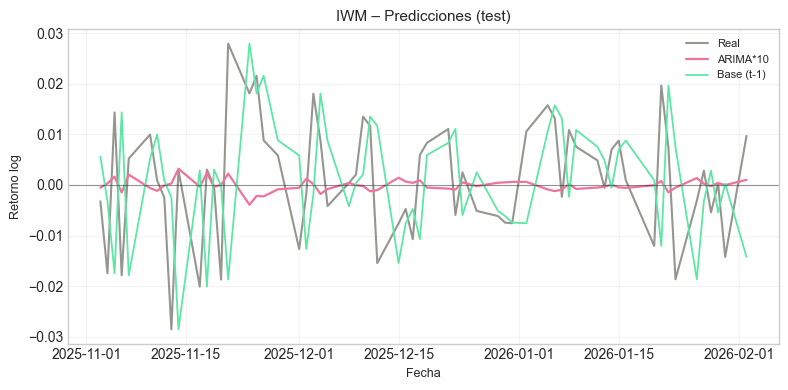

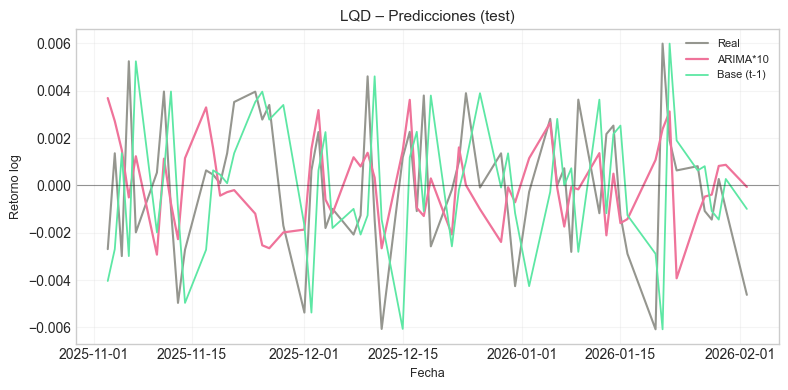

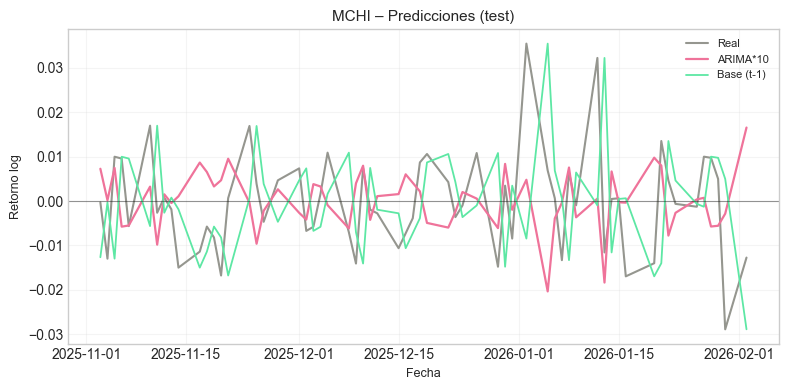

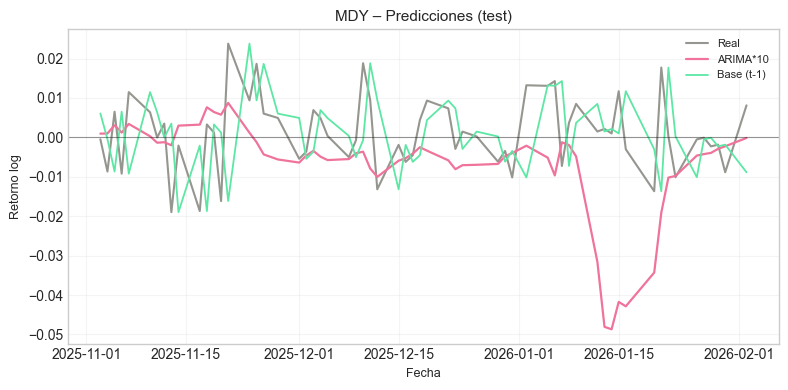

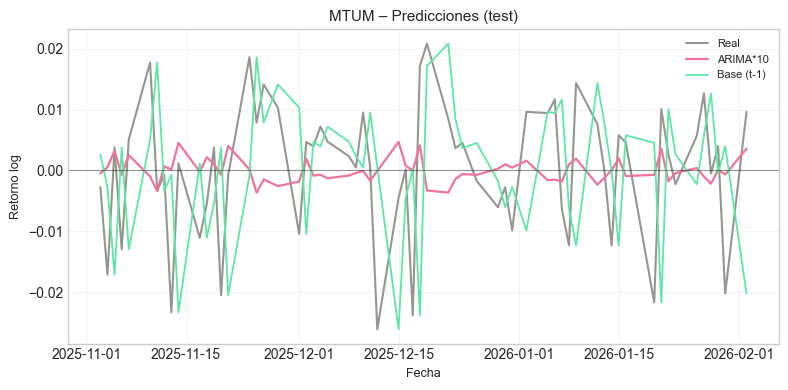

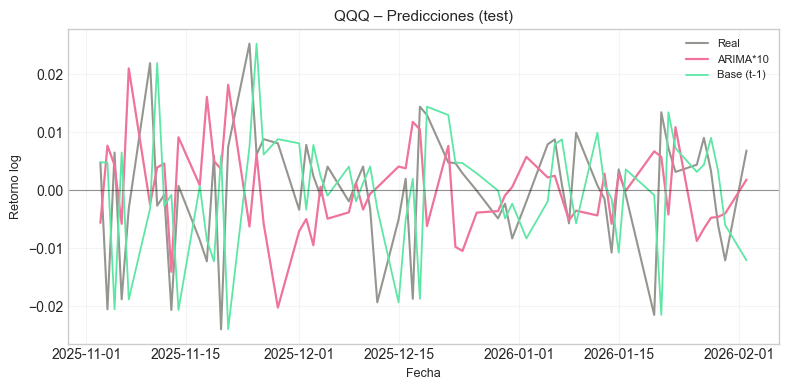

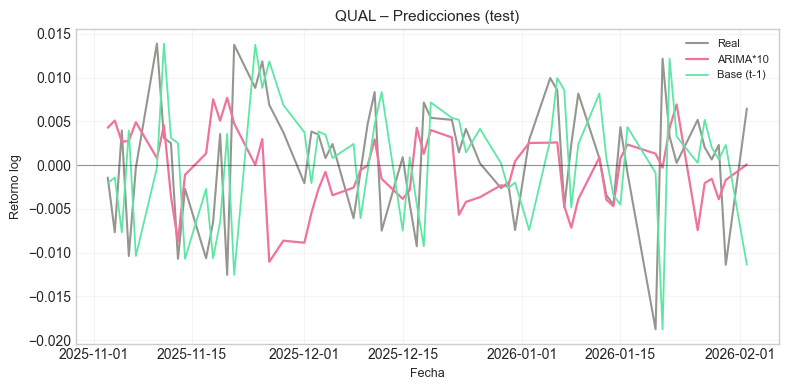

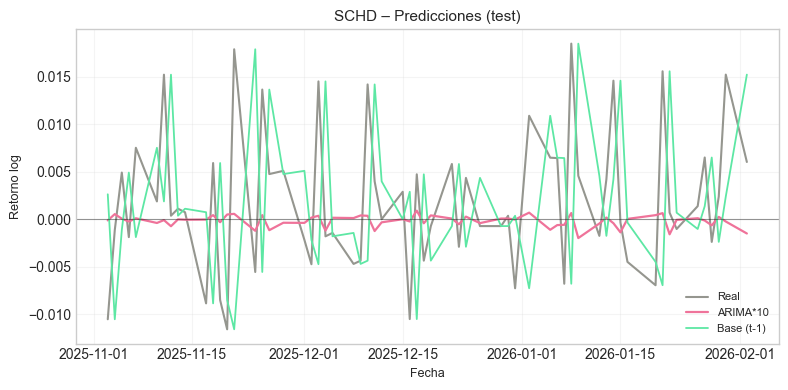

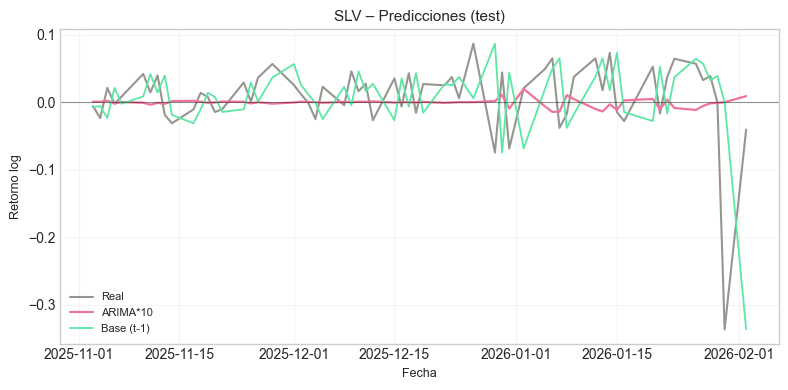

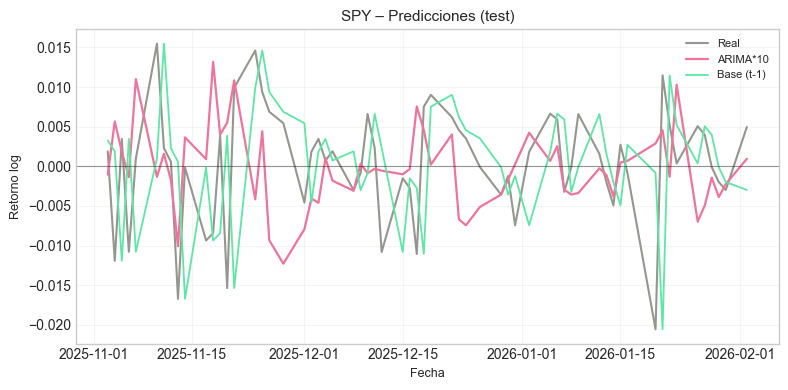

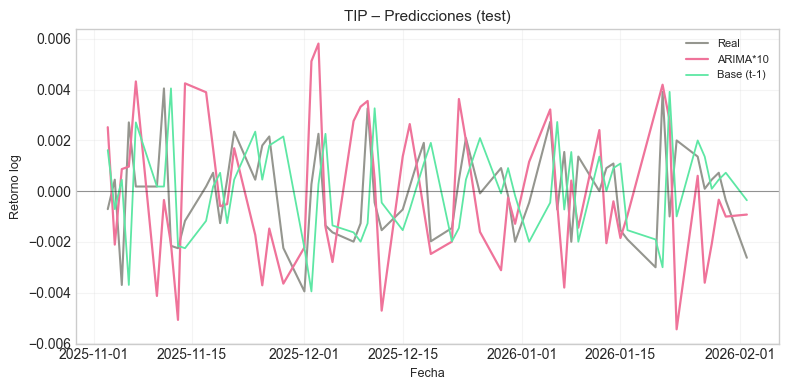

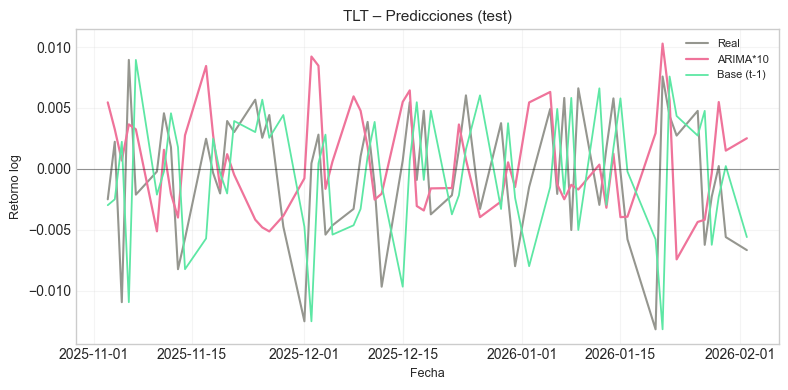

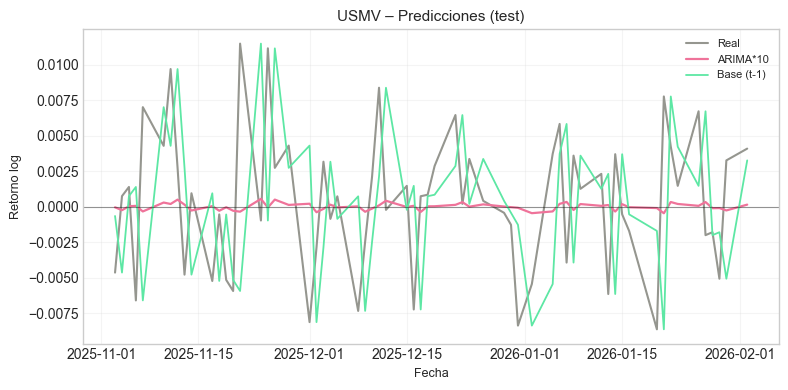

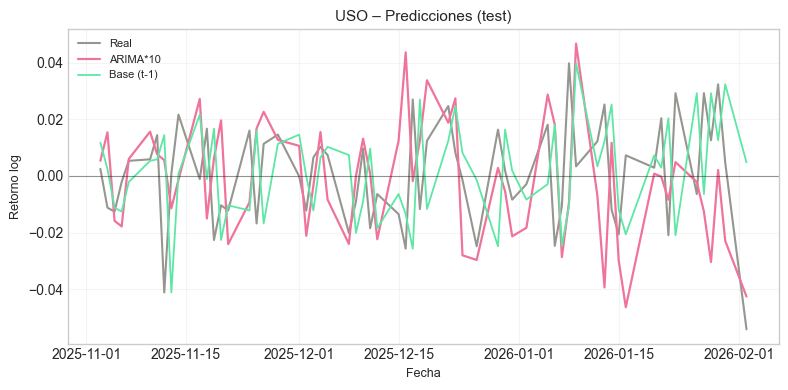

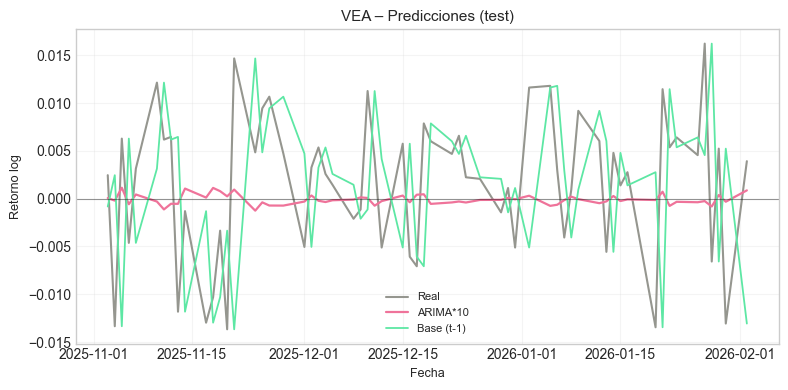

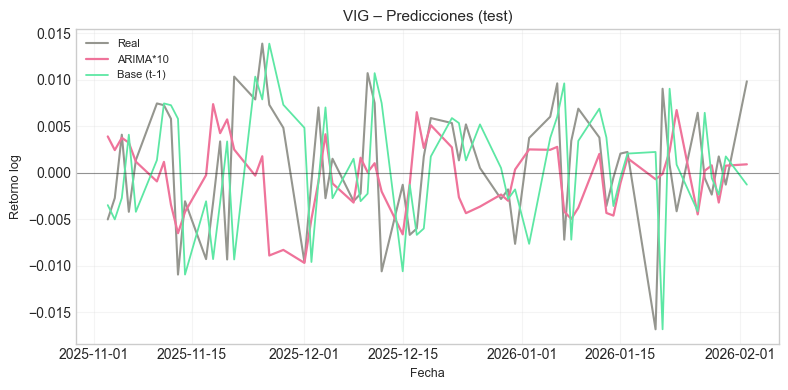

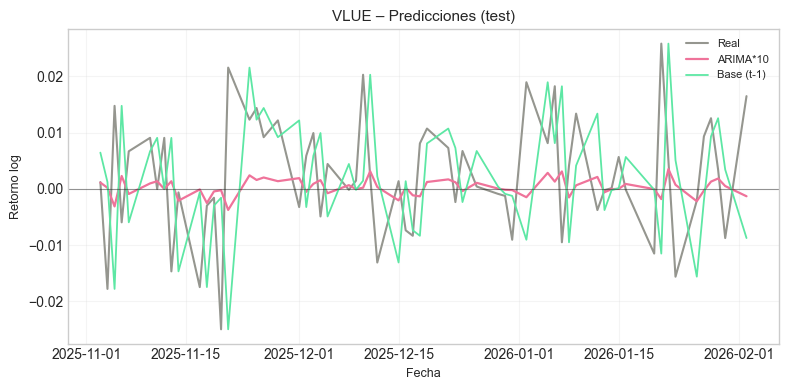

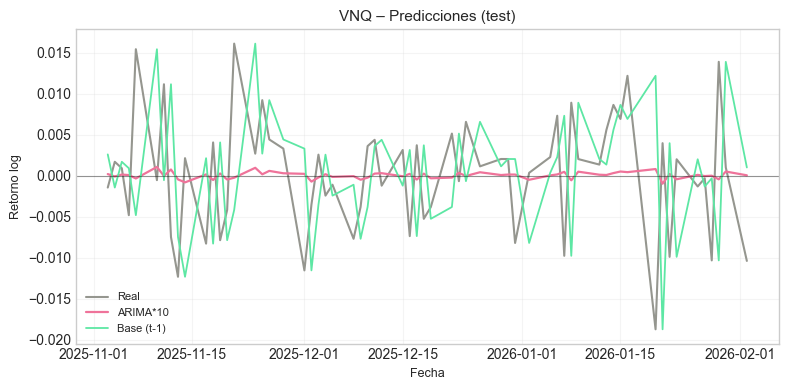

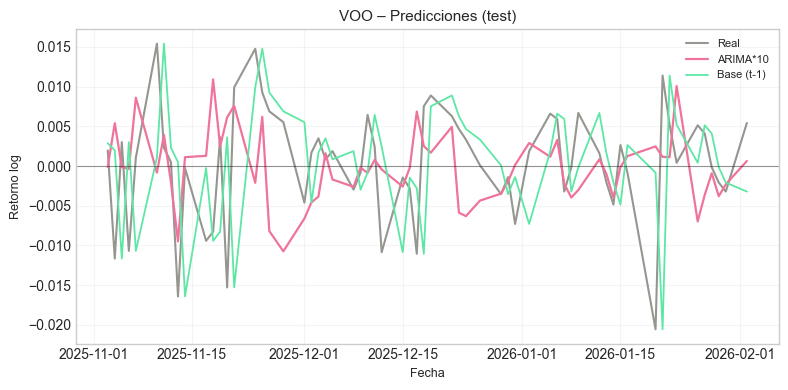

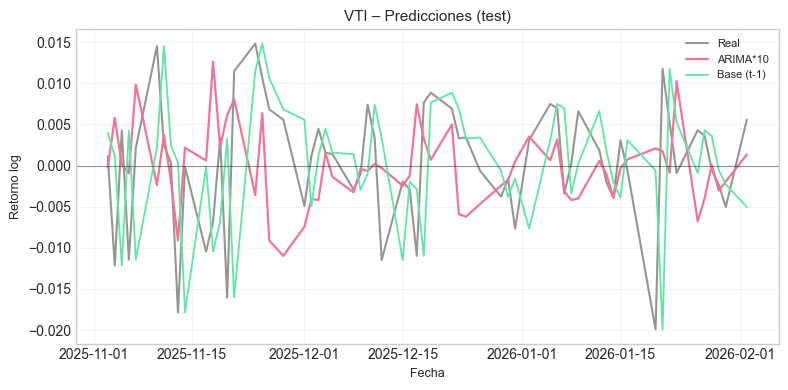

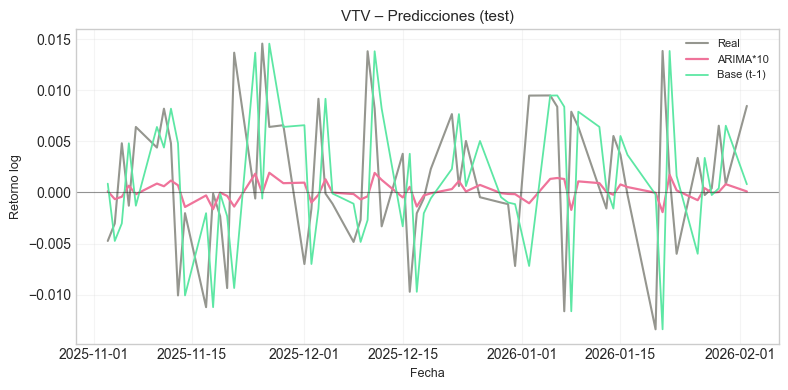

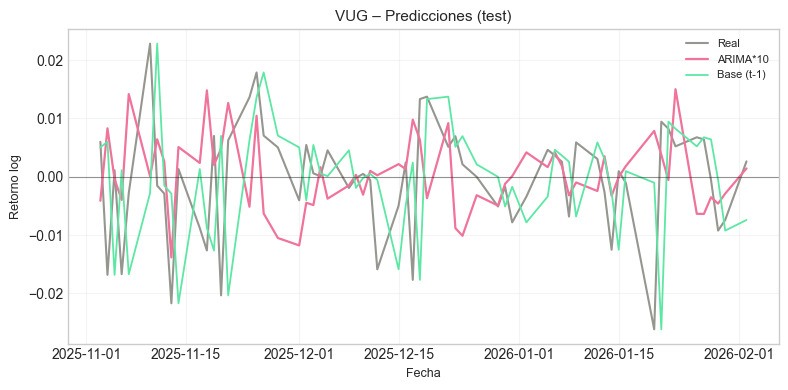

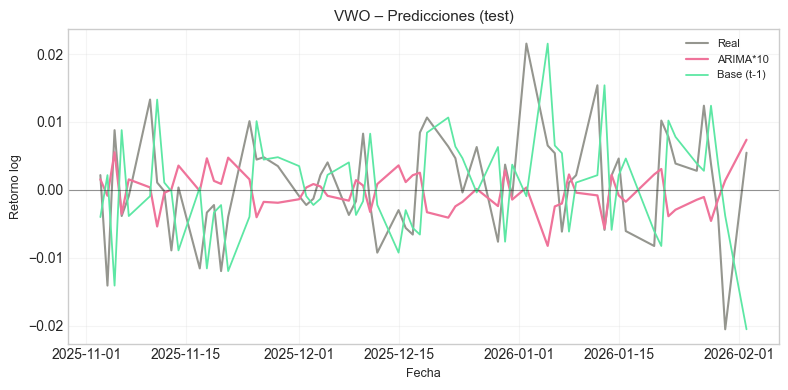

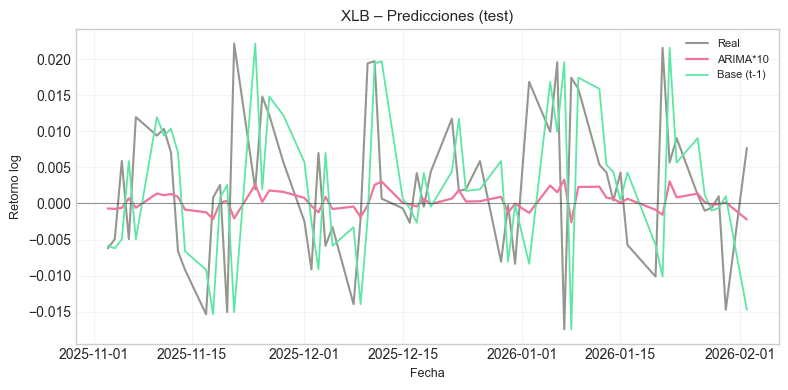

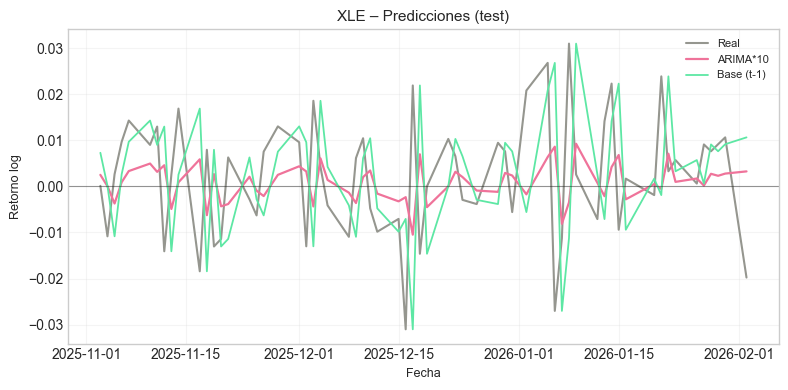

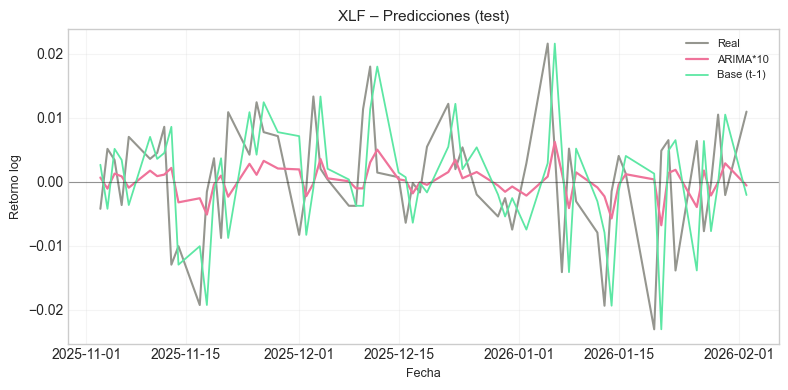

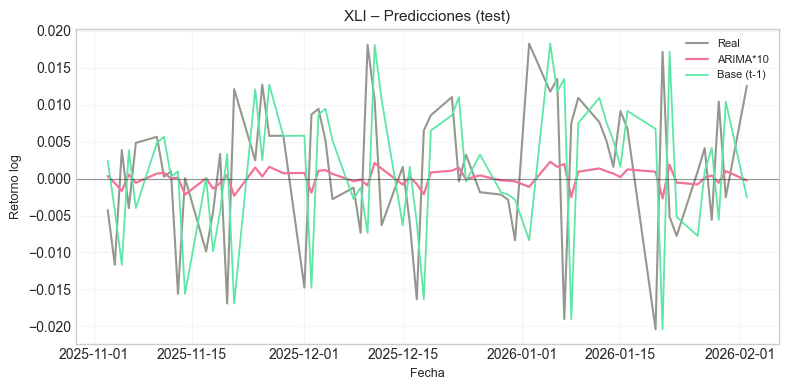

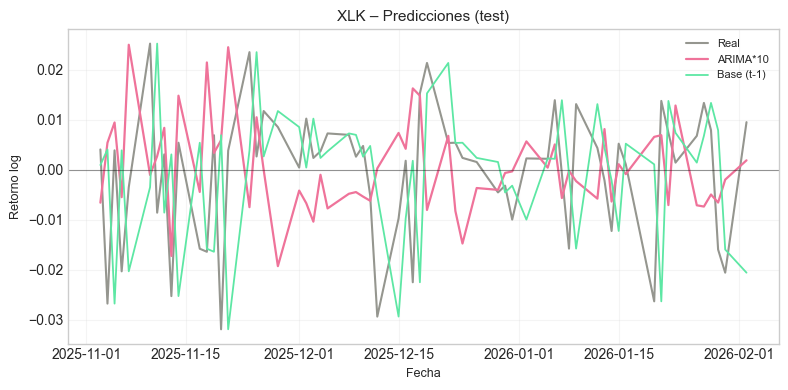

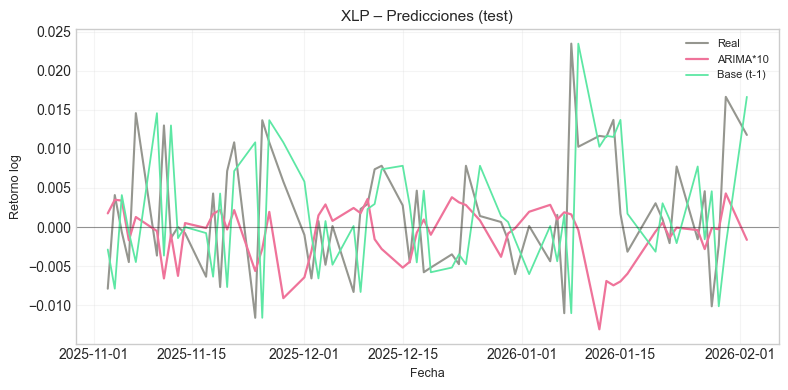

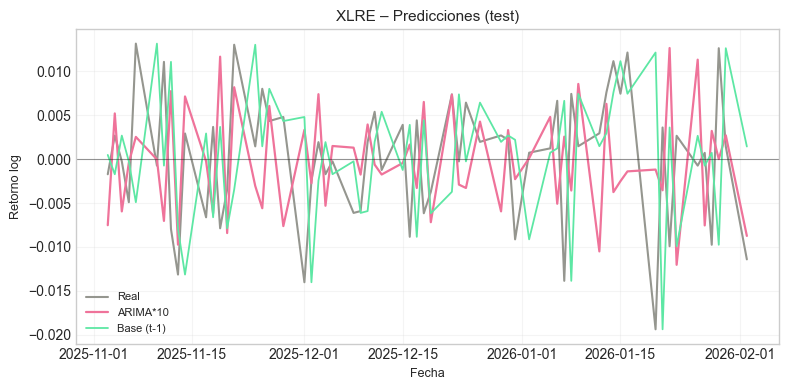

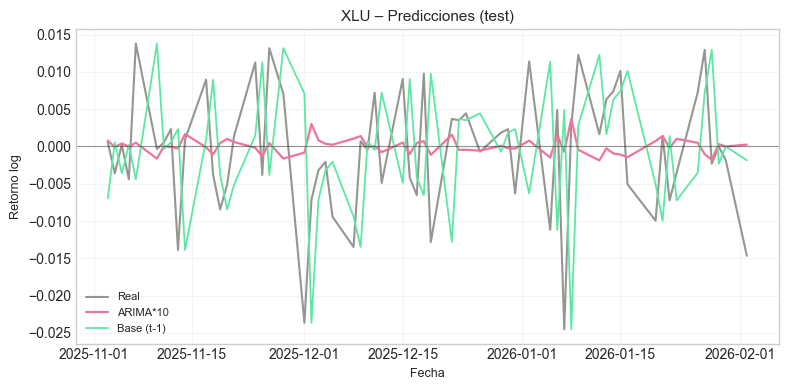

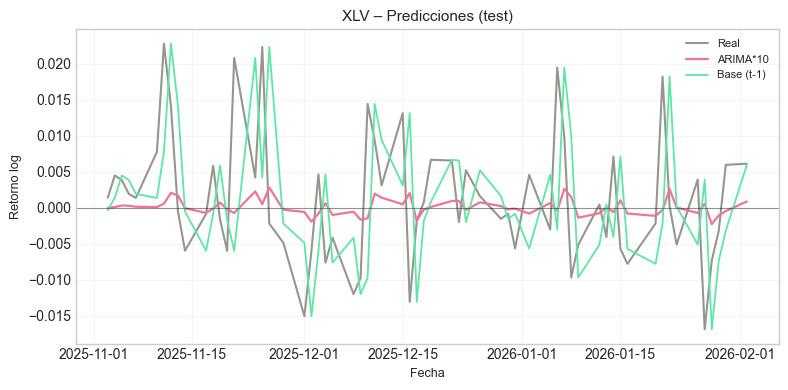

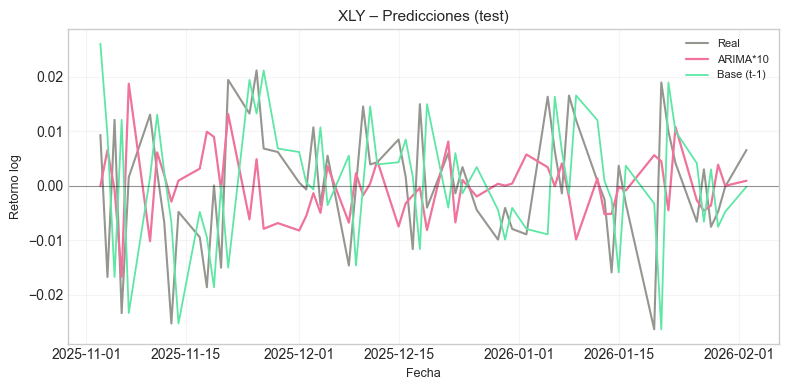

In [41]:
import matplotlib.pyplot as plt

# Colores suaves y bonitos
color_real  = "#95968F"   # gris oscuro elegante
color_arima = "#EF739A"   # azul limpio
color_base  = "#5DE7A4"   # naranja suave

for etf, df in resultados_preds.items():
    
    plt.figure(figsize=(8, 4))
    
    # Serie real
    plt.plot(
        df["real"],
        label="Real",
        color=color_real,
        linewidth=1.5
    )
    
    # ARIMA (sin multiplicar por 10 para mantener limpieza visual)
    plt.plot(
        df["arima"]*10,
        label="ARIMA*10",
        color=color_arima,
        linewidth=1.6
    )
    
    # Modelo base
    plt.plot(
        df["base"],
        label="Base (t-1)",
        color=color_base,
        linewidth=1.3
    )
    
    # Línea horizontal en 0 muy discreta
    plt.axhline(0, color="black", linewidth=0.8, alpha=0.4)
    
    # Título simple
    plt.title(f"{etf} – Predicciones (test)", fontsize=11)
    plt.xlabel("Fecha", fontsize=9)
    plt.ylabel("Retorno log", fontsize=9)
    
    # Grid muy sutil
    plt.grid(alpha=0.2)
    
    # Leyenda simple
    plt.legend(fontsize=8, frameon=False)
    
    plt.tight_layout()
    plt.show()

### Kappa de Cohen

A veces no importa tanto el valor exacto del error, sino si el modelo acierta la dirección del movimiento (signo positivo o negativo).

In [42]:
from sklearn.metrics import cohen_kappa_score, accuracy_score

metricas_direccionales = []

for etf, df in resultados_preds.items():
    # Creamos las variables binarias (1 si sube > 0, 0 si baja o igual)
    real_dir = (df["real"] > 0).astype(int)
    arima_dir = (df["arima"] > 0).astype(int)
    base_dir = (df["base"] > 0).astype(int)
    # Nota: El modelo ZEROS no tiene dirección (siempre es 0), así que no lo incluimos en esta comparación.

    # Cálculo de Kappa de Cohen 
    kappa_arima = cohen_kappa_score(real_dir, arima_dir)
    kappa_base = cohen_kappa_score(real_dir, base_dir)

    # Número de aciertos de la dirección dividido por el total de predicciones.
    Accuracy_arima = accuracy_score(real_dir, arima_dir)
    Accuracy_base = accuracy_score(real_dir, base_dir)

    metricas_direccionales.append({
        "ETF": etf,
        "Kappa_ARIMA": kappa_arima,
        "Kappa_BASE": kappa_base,
        "Accuracy_ARIMA": f"{Accuracy_arima:.2%}",
        "Accuracy_BASE": f"{Accuracy_base:.2%}"
    })

# Mostrar tabla de resultados direccionales
df_direccional = pd.DataFrame(metricas_direccionales).set_index("ETF")
print("Análisis de Dirección (Sube/Baja):")
display(df_direccional)

Análisis de Dirección (Sube/Baja):


,Kappa_ARIMA,Kappa_BASE,Accuracy_ARIMA,Accuracy_BASE
ETF,,,,
AGG,0.062565,0.028213,53.23%,51.61%
BND,0.223382,-0.107143,61.29%,45.16%
DBC,0.068394,-0.021254,53.23%,50.00%
DIA,0.015873,0.015873,51.61%,51.61%
DVY,-0.021254,-0.021254,50.00%,50.00%
EEM,-0.042813,0.044633,46.77%,53.23%
EFA,0.092683,-0.061878,51.61%,50.00%
EWG,0.032258,0.212155,51.61%,62.90%
EWJ,0.048106,-0.049735,51.61%,48.39%


## Modelo GARCH (Volatilidad)

En finanzas, la volatilidad no es constante. Hay periodos de calma y periodos de turbulencia. A esto se le llama Clustering de Volatilidad: si hoy hubo un movimiento brusco, es muy probable que mañana también lo haya.

ARIMA: Se encarga de la Media (¿Cuánto va a subir o bajar?).

GARCH: Se encarga de la Varianza (¿Cuánto se va a desviar de esa predicción?).

In [45]:
# ! pip install arch
from arch import arch_model